# Vision Tracker Evaluation — RT-DETR + ByteTrack / BOT-SORT

Runs the RT-DETR model on all vision MOT sequences, compares predictions to GT,
and reports standard MOT metrics for **both ByteTrack and BOT-SORT** in separate tables.

**Model:** `solaqua_fish_improved_fix/rtdetr_fish_improved_f/weights/best.pt`   
**Class:** fish (class_id = 1)  
**Metric matching:** IoU ≥ 0.5

Run from `tracking/` directory.

In [1]:
print("Jupyter OK!")

Jupyter OK!


In [2]:
import sys
sys.path.insert(0, "..")  # make repo root importable

import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

from tracking.utils.mot_metrics import (
    load_gt, run_inference, img_dir_for, frame_map,
    collect_images,
    compute_metrics, compute_hota, format_summary, build_summary_table,
    plot_metrics_bar, plot_error_breakdown,
    plot_track_comparison, plot_det_timeline, plot_id_switches,
)

plt.rcParams.update({"figure.dpi": 130, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})


/workspace/aquaculture-perception/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# ── Paths ──────────────────────────────────────────────────────────────────────
REPO        = Path("..").resolve()
VISION_ROOT = REPO / "data-processing" / "vision" / "MOT"
MODEL_PATH  = REPO / "runs/detect/outputs/training/solaqua_fish_improved_fix/rtdetr_fish_improved_f/weights/best.pt"

# ── Sequence selection ─────────────────────────────────────────────────────────
SELECTED_SEQUENCES = [
    "2024-08-20_14-31-29",
    "2024-08-20_17-02-00",
    "2024-08-20_17-14-36",
    # "2024-08-20_17-39-32",
    "2024-08-20_17-55-40",
]

# ── Inference settings ─────────────────────────────────────────────────────────
CONF        = 0.25
IOU_NMS     = 0.45
IOU_MATCH   = 0.5
DEVICE      = "cuda:0"
FRAME_RATE  = 30
TRACKERS    = ["bytetrack", "botsort"]  # both will be evaluated

MODEL_NAME     = MODEL_PATH.parent.parent.name
MOT_OUTPUT_DIR = Path("outputs/inference_annotation_MOT11")
MOT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

all_seqs  = sorted([p.name for p in VISION_ROOT.iterdir() if p.is_dir()])
SEQUENCES = [s for s in all_seqs if s in SELECTED_SEQUENCES] if SELECTED_SEQUENCES else all_seqs

print(f"Model      : {MODEL_PATH.name}")
print(f"Device     : {DEVICE}")
print(f"Trackers   : {TRACKERS}")
print(f"Sequences ({len(SEQUENCES)}):")
for s in SEQUENCES:
    print(f"  {s}")


Model      : best.pt
Device     : cuda:0
Trackers   : ['bytetrack', 'botsort']
Sequences (4):
  2024-08-20_14-31-29
  2024-08-20_17-02-00
  2024-08-20_17-14-36
  2024-08-20_17-55-40


## 1  Run inference — both trackers
GT is loaded once (same for both trackers). Predictions are cached in memory
and saved as MOT .txt files under `outputs/inference_annotation_MOT11/`.

In [4]:
gt_dfs          = {}   # {seq: DataFrame}  — fish GT, shared across trackers
total_frames    = {}   # {seq: int}
pred_by_tracker = {t: {} for t in TRACKERS}  # {tracker: {seq: DataFrame}}

# ── Load GT (class 1 = fish) ──────────────────────────────────────────────────
for seq in SEQUENCES:
    seq_path          = VISION_ROOT / seq
    idir              = img_dir_for(seq_path, "vision")
    gt_dfs[seq]       = load_gt(seq_path / "gt" / "gt.txt", idir, class_id=1)
    total_frames[seq] = len(list(idir.glob("*.jpg")))

# ── Run inference for each tracker ────────────────────────────────────────────
for tracker in TRACKERS:
    run_tag = f"{MODEL_NAME}+{tracker}"
    print(f"\n── Tracker: {tracker} ──")
    for seq in SEQUENCES:
        seq_path  = VISION_ROOT / seq
        idir      = img_dir_for(seq_path, "vision")
        pred      = run_inference(MODEL_PATH, idir,
                                  conf=CONF, iou=IOU_NMS,
                                  device=DEVICE, frame_rate=FRAME_RATE,
                                  tracker_type=tracker, desc=seq)
        pred_fish = pred[pred["class_id"] == 1].copy()
        pred_by_tracker[tracker][seq] = pred_fish

        mot_lines = [
            f"{int(row.frame_id)},{int(row.track_id)},"
            f"{row.x:.2f},{row.y:.2f},{row.w:.2f},{row.h:.2f},"
            f"1,{int(row.class_id)},1.000000"
            for row in pred_fish.sort_values(["frame_id", "track_id"]).itertuples()
        ]
        mot_path = MOT_OUTPUT_DIR / f"INFERENCE_MOT11_{seq}_{run_tag}.txt"
        mot_path.write_text("\n".join(mot_lines), encoding="utf-8")
        print(f"  {seq}: GT={len(gt_dfs[seq])}  Pred={len(pred_fish)}  -> {mot_path.name}")



── Tracker: bytetrack ──


2024-08-20_14-31-29: 100%|██████████| 1500/1500 [01:19<00:00, 18.89it/s]


  2024-08-20_14-31-29: GT=4967  Pred=4549  -> INFERENCE_MOT11_2024-08-20_14-31-29_rtdetr_fish_improved_f+bytetrack.txt


2024-08-20_17-02-00: 100%|██████████| 1212/1212 [01:01<00:00, 19.72it/s]


  2024-08-20_17-02-00: GT=1104  Pred=1074  -> INFERENCE_MOT11_2024-08-20_17-02-00_rtdetr_fish_improved_f+bytetrack.txt


...

  2024-08-20_17-02-00: GT=1104  Pred=1076  -> INFERENCE_MOT11_2024-08-20_17-02-00_rtdetr_fish_improved_f+botsort.txt


2024-08-20_17-14-36: 100%|██████████| 834/834 [00:36<00:00, 22.60it/s]


  2024-08-20_17-14-36: GT=899  Pred=875  -> INFERENCE_MOT11_2024-08-20_17-14-36_rtdetr_fish_improved_f+botsort.txt


2024-08-20_17-55-40: 100%|██████████| 796/796 [00:33<00:00, 23.91it/s]

  2024-08-20_17-55-40: GT=1667  Pred=1459  -> INFERENCE_MOT11_2024-08-20_17-55-40_rtdetr_fish_improved_f+botsort.txt


## 2  Compute metrics

In [5]:
accs_by_tracker    = {}
results_by_tracker = {}

for tracker in TRACKERS:
    run_tag = f"{MODEL_NAME}+{tracker}"
    accs    = {}
    results = {}
    for seq in SEQUENCES:
        acc, summary = compute_metrics(gt_dfs[seq], pred_by_tracker[tracker][seq],
                                       iou_threshold=IOU_MATCH)
        hota = compute_hota(gt_dfs[seq], pred_by_tracker[tracker][seq])
        for k, v in hota.items():
            summary[k] = v
        accs[seq]    = acc
        results[seq] = summary
    accs_by_tracker[tracker]    = accs
    results_by_tracker[tracker] = results

    print(f"\n── {tracker.upper()} — Vision fish metrics ──")
    for seq in SEQUENCES:
        h = results[seq]
        print(f"  {seq[-8:]}  "
              f"HOTA={float(h['hota'].iloc[0])*100:.1f}%  "
              f"MOTA={float(h['mota'].iloc[0])*100:.1f}%  "
              f"IDF1={float(h['idf1'].iloc[0])*100:.1f}%  "
              f"IDSW={int(h['num_switches'].iloc[0])}")
    print(f"\nRun: {run_tag}")
    display(build_summary_table(results))



── BYTETRACK — Vision fish metrics ──
  14-31-29  HOTA=81.2%  MOTA=89.1%  IDF1=87.9%  IDSW=22
  17-02-00  HOTA=96.2%  MOTA=95.8%  IDF1=97.9%  IDSW=0
  17-14-36  HOTA=86.1%  MOTA=88.5%  IDF1=86.1%  IDSW=7
  17-55-40  HOTA=75.8%  MOTA=77.0%  IDF1=82.0%  IDSW=30

Run: rtdetr_fish_improved_f+bytetrack


,Sequence,HOTA,DetA,AssA,MOTA,IDF1,MOTP,Recall,Precision,FP,FN,IDSW,MT,ML,GT tracks
0,14-31-29,81.2%,77.3%,89.1%,89.1%,87.9%,6.7%,90.6%,98.9%,51,469,22,42,0,53
1,17-02-00,96.2%,92.7%,100.0%,95.8%,97.9%,2.1%,96.6%,99.3%,8,38,0,21,1,22
2,17-14-36,86.1%,84.9%,87.7%,88.5%,86.1%,2.8%,93.0%,96.2%,33,63,7,22,2,30
3,17-55-40,75.8%,68.5%,86.5%,77.0%,82.0%,7.6%,83.0%,95.2%,70,284,30,41,3,65



── BOTSORT — Vision fish metrics ──
  14-31-29  HOTA=83.0%  MOTA=89.7%  IDF1=89.2%  IDSW=12
  17-02-00  HOTA=96.1%  MOTA=95.7%  IDF1=97.8%  IDSW=0
  17-14-36  HOTA=91.9%  MOTA=89.7%  IDF1=94.5%  IDSW=1
  17-55-40  HOTA=76.5%  MOTA=79.3%  IDF1=82.8%  IDSW=15

Run: rtdetr_fish_improved_f+botsort


,Sequence,HOTA,DetA,AssA,MOTA,IDF1,MOTP,Recall,Precision,FP,FN,IDSW,MT,ML,GT tracks
0,14-31-29,83.0%,77.6%,92.8%,89.7%,89.2%,6.6%,91.0%,98.9%,51,449,12,42,0,53
1,17-02-00,96.1%,92.5%,100.0%,95.7%,97.8%,2.1%,96.6%,99.1%,10,38,0,21,1,22
2,17-14-36,91.9%,85.4%,99.4%,89.7%,94.5%,2.8%,93.5%,96.1%,34,58,1,23,2,30
3,17-55-40,76.5%,69.2%,87.2%,79.3%,82.8%,7.5%,83.9%,95.8%,61,269,15,42,2,65


## 3  Metrics bar charts

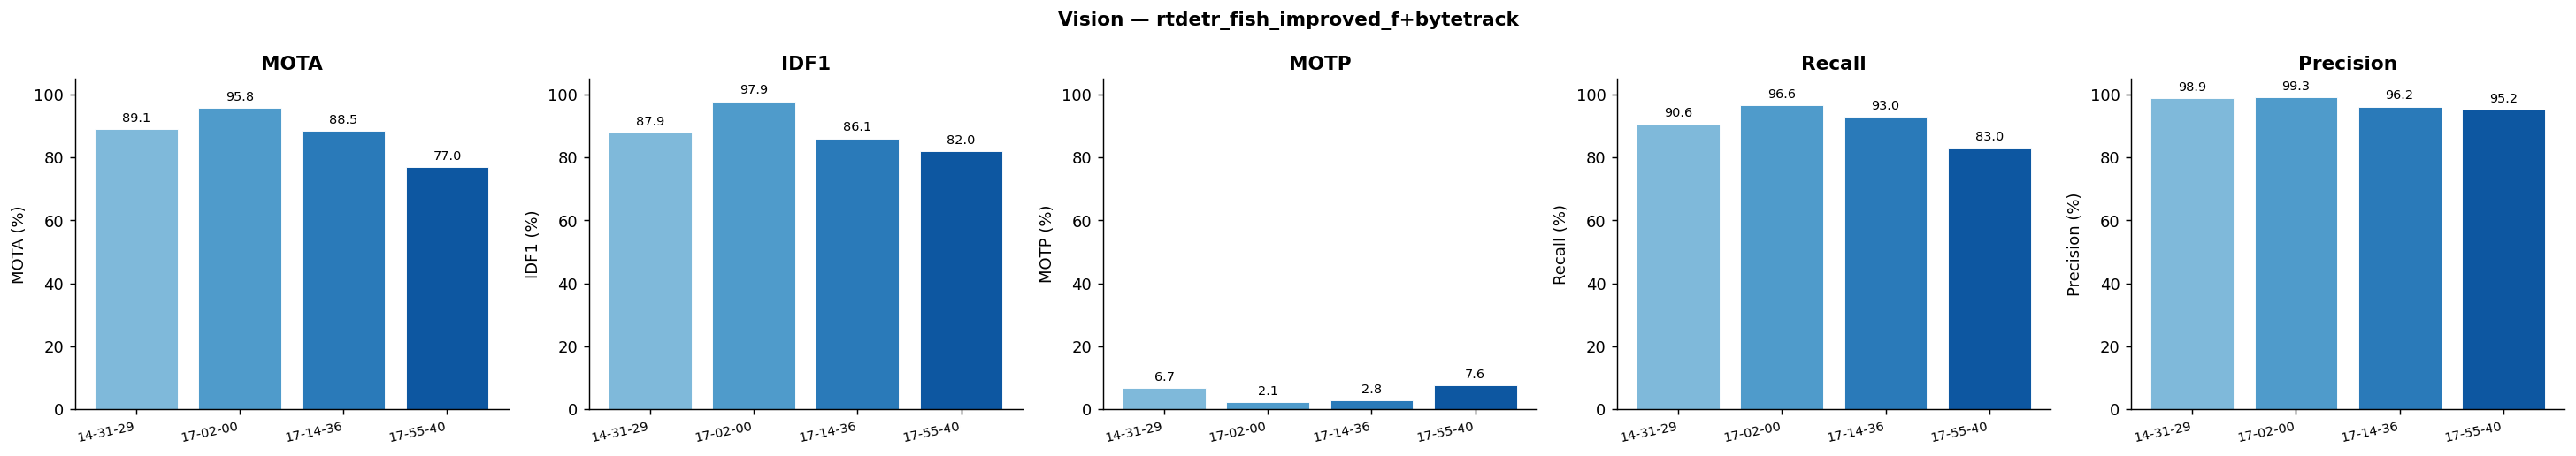

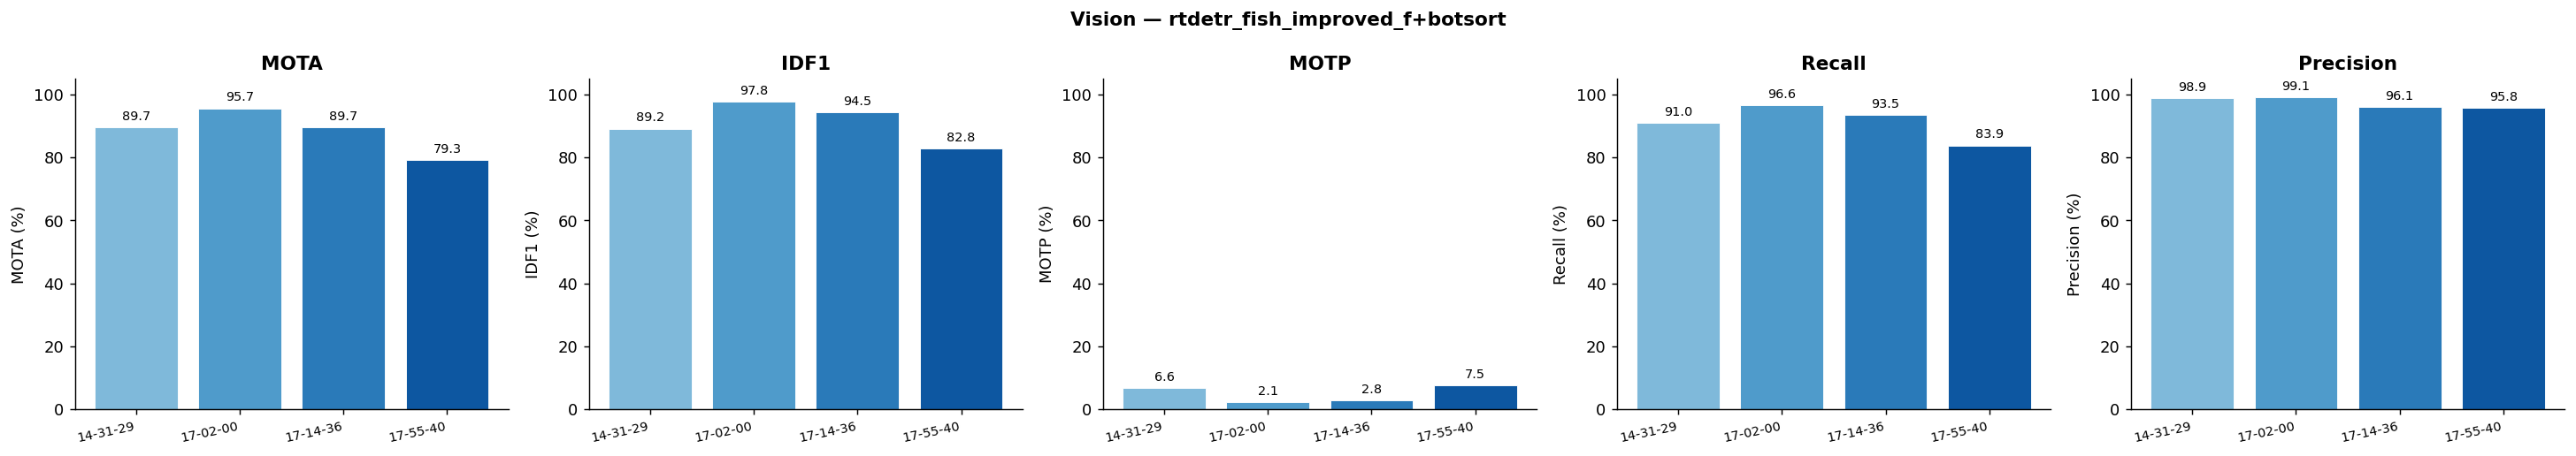

In [6]:
for tracker in TRACKERS:
    run_tag = f"{MODEL_NAME}+{tracker}"
    fig = plot_metrics_bar(results_by_tracker[tracker],
                           metrics=("MOTA", "IDF1", "MOTP", "Recall", "Precision"),
                           title=f"Vision — {run_tag}")
    plt.savefig(f"outputs/vision_{run_tag}_metrics_bar.png", dpi=150, bbox_inches="tight")
    plt.show()


## 4  Error breakdown — FP / FN / ID switches

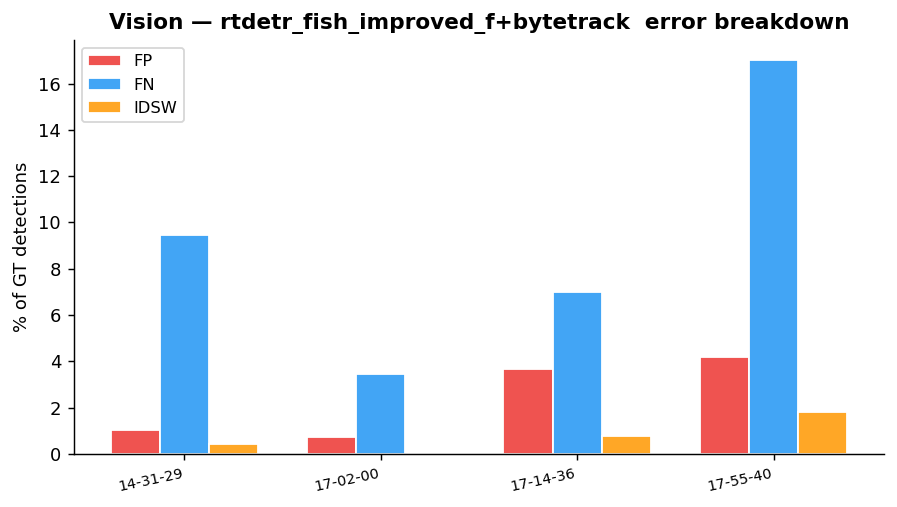

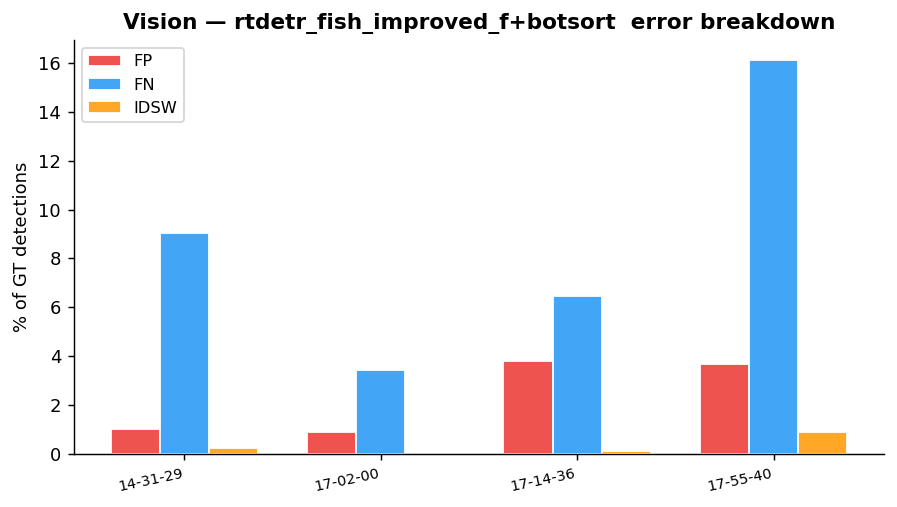

In [ ]:
for tracker in TRACKERS:
    run_tag = f"{MODEL_NAME}+{tracker}"
    fig = plot_error_breakdown(results_by_tracker[tracker],
                               title=f"Vision — {run_tag}  error breakdown")
    # plt.savefig(f"outputs/vision_{run_tag}_error_breakdown.png", dpi=150, bbox_inches="tight")
    plt.show()


## 5  GT vs predicted track count

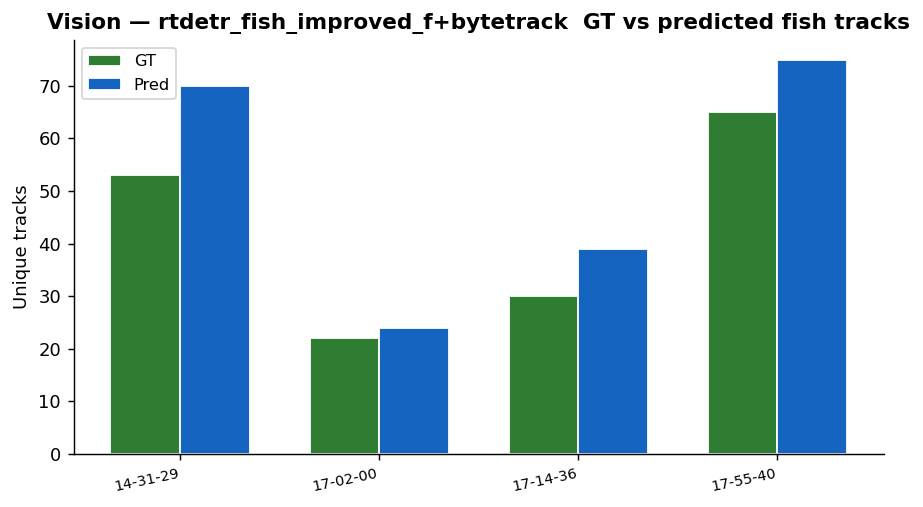

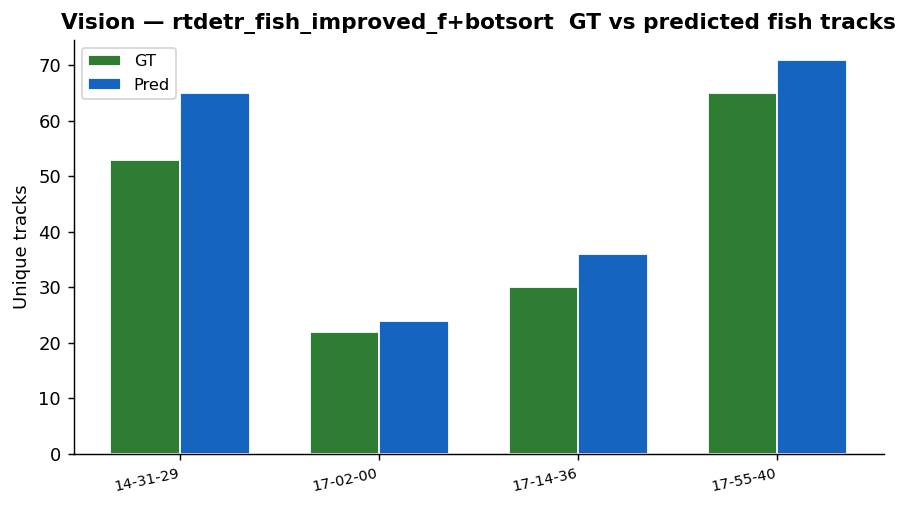

In [ ]:
for tracker in TRACKERS:
    run_tag = f"{MODEL_NAME}+{tracker}"
    fig = plot_track_comparison(gt_dfs, pred_by_tracker[tracker])
    plt.title(f"Vision — {run_tag}  GT vs predicted fish tracks", fontweight="bold")
    # plt.savefig(f"outputs/vision_{run_tag}_track_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()


## 6  Detection count per frame — GT vs predicted

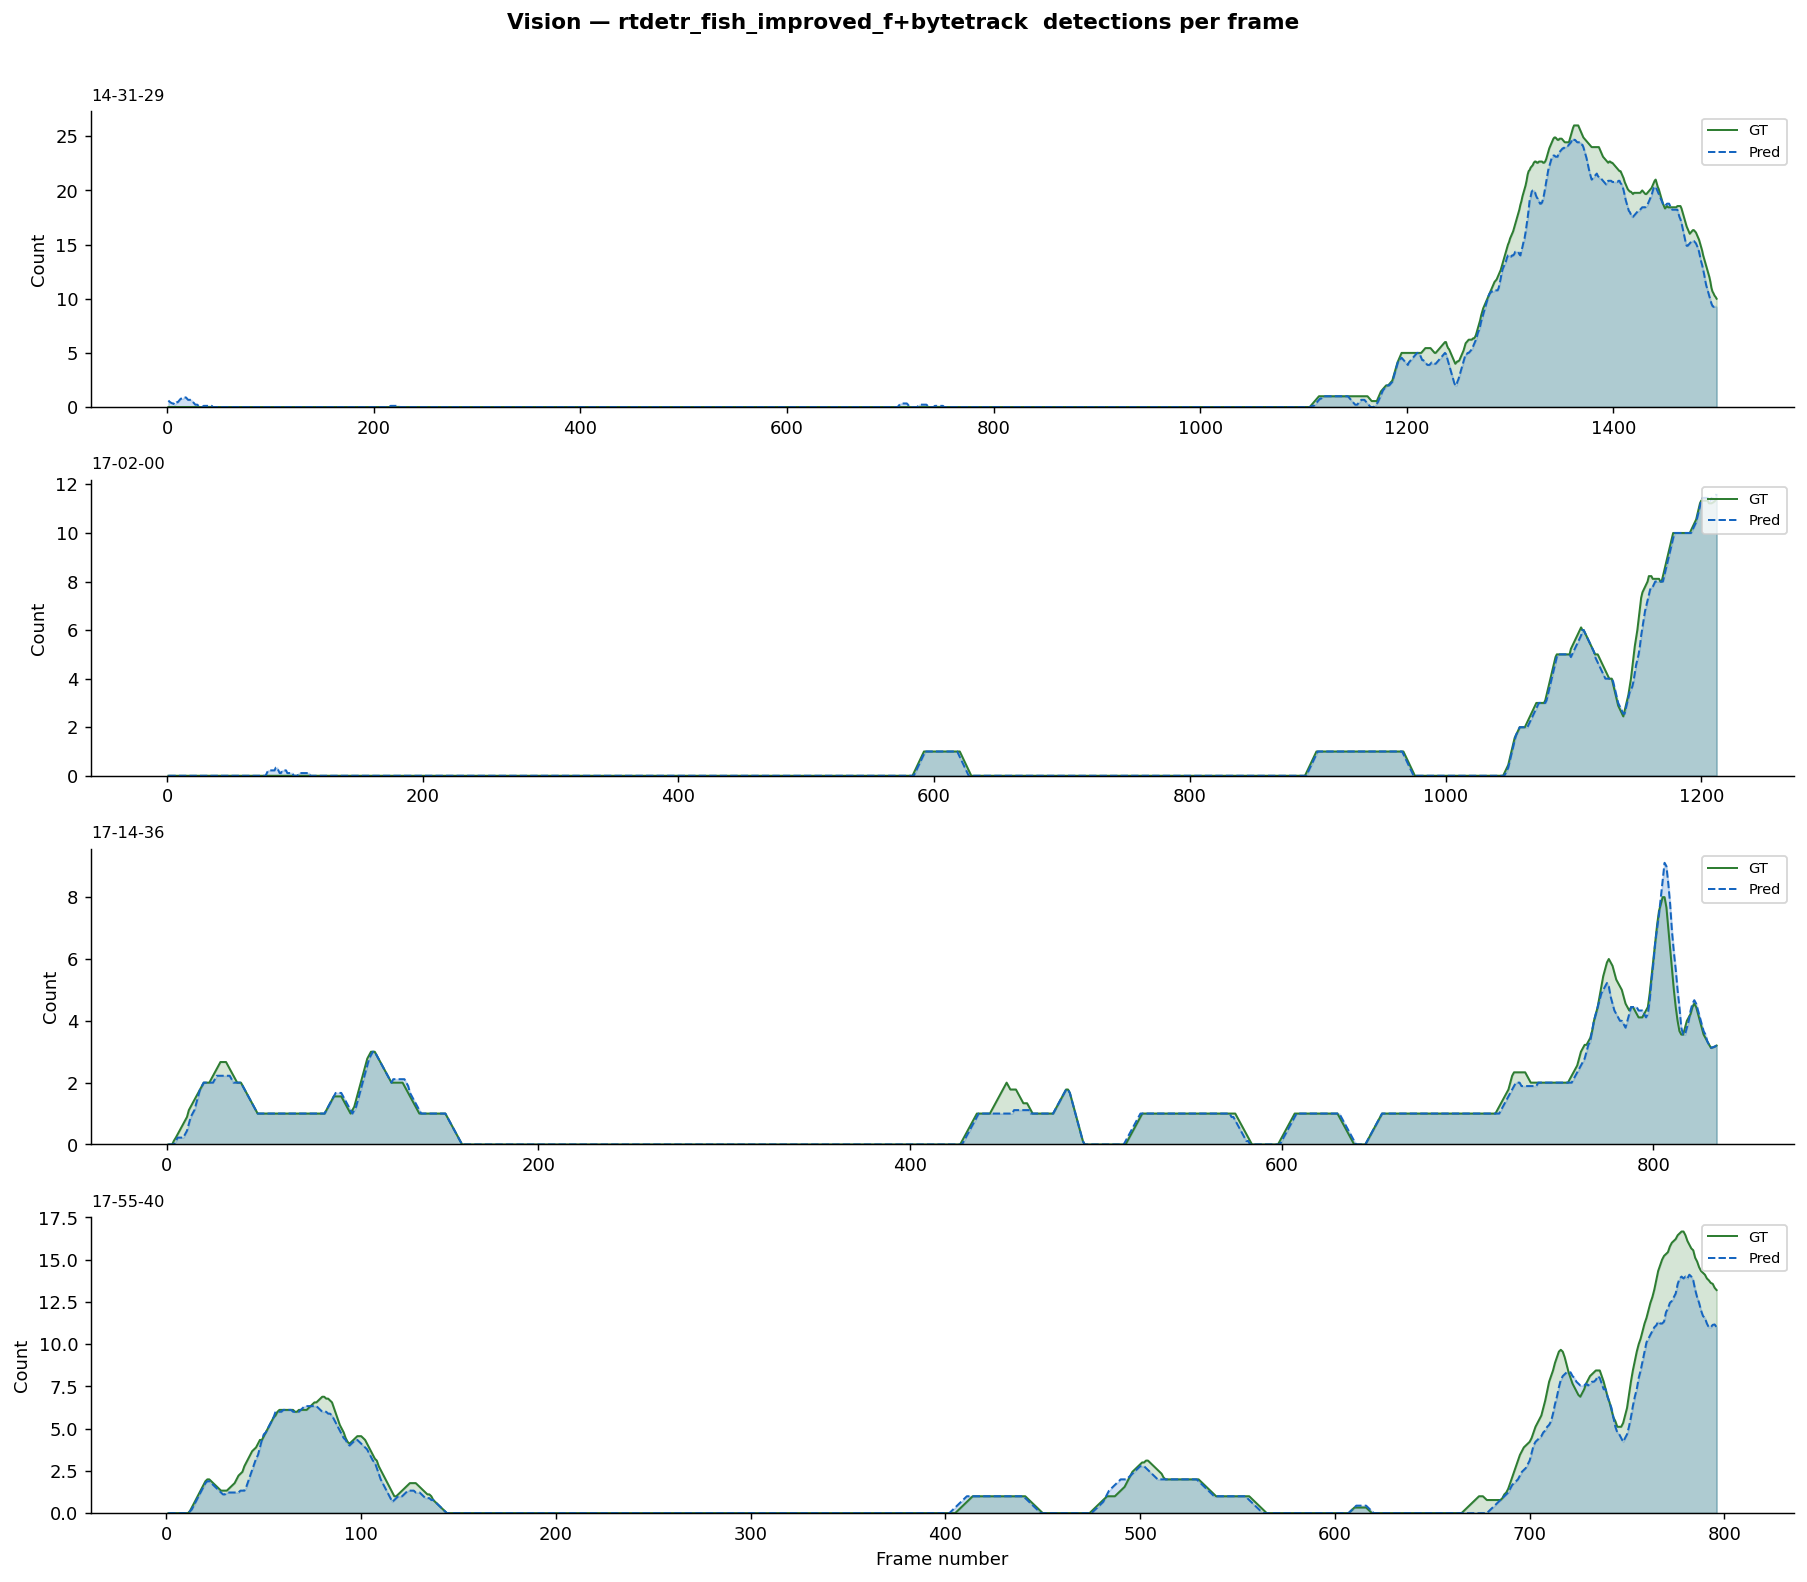

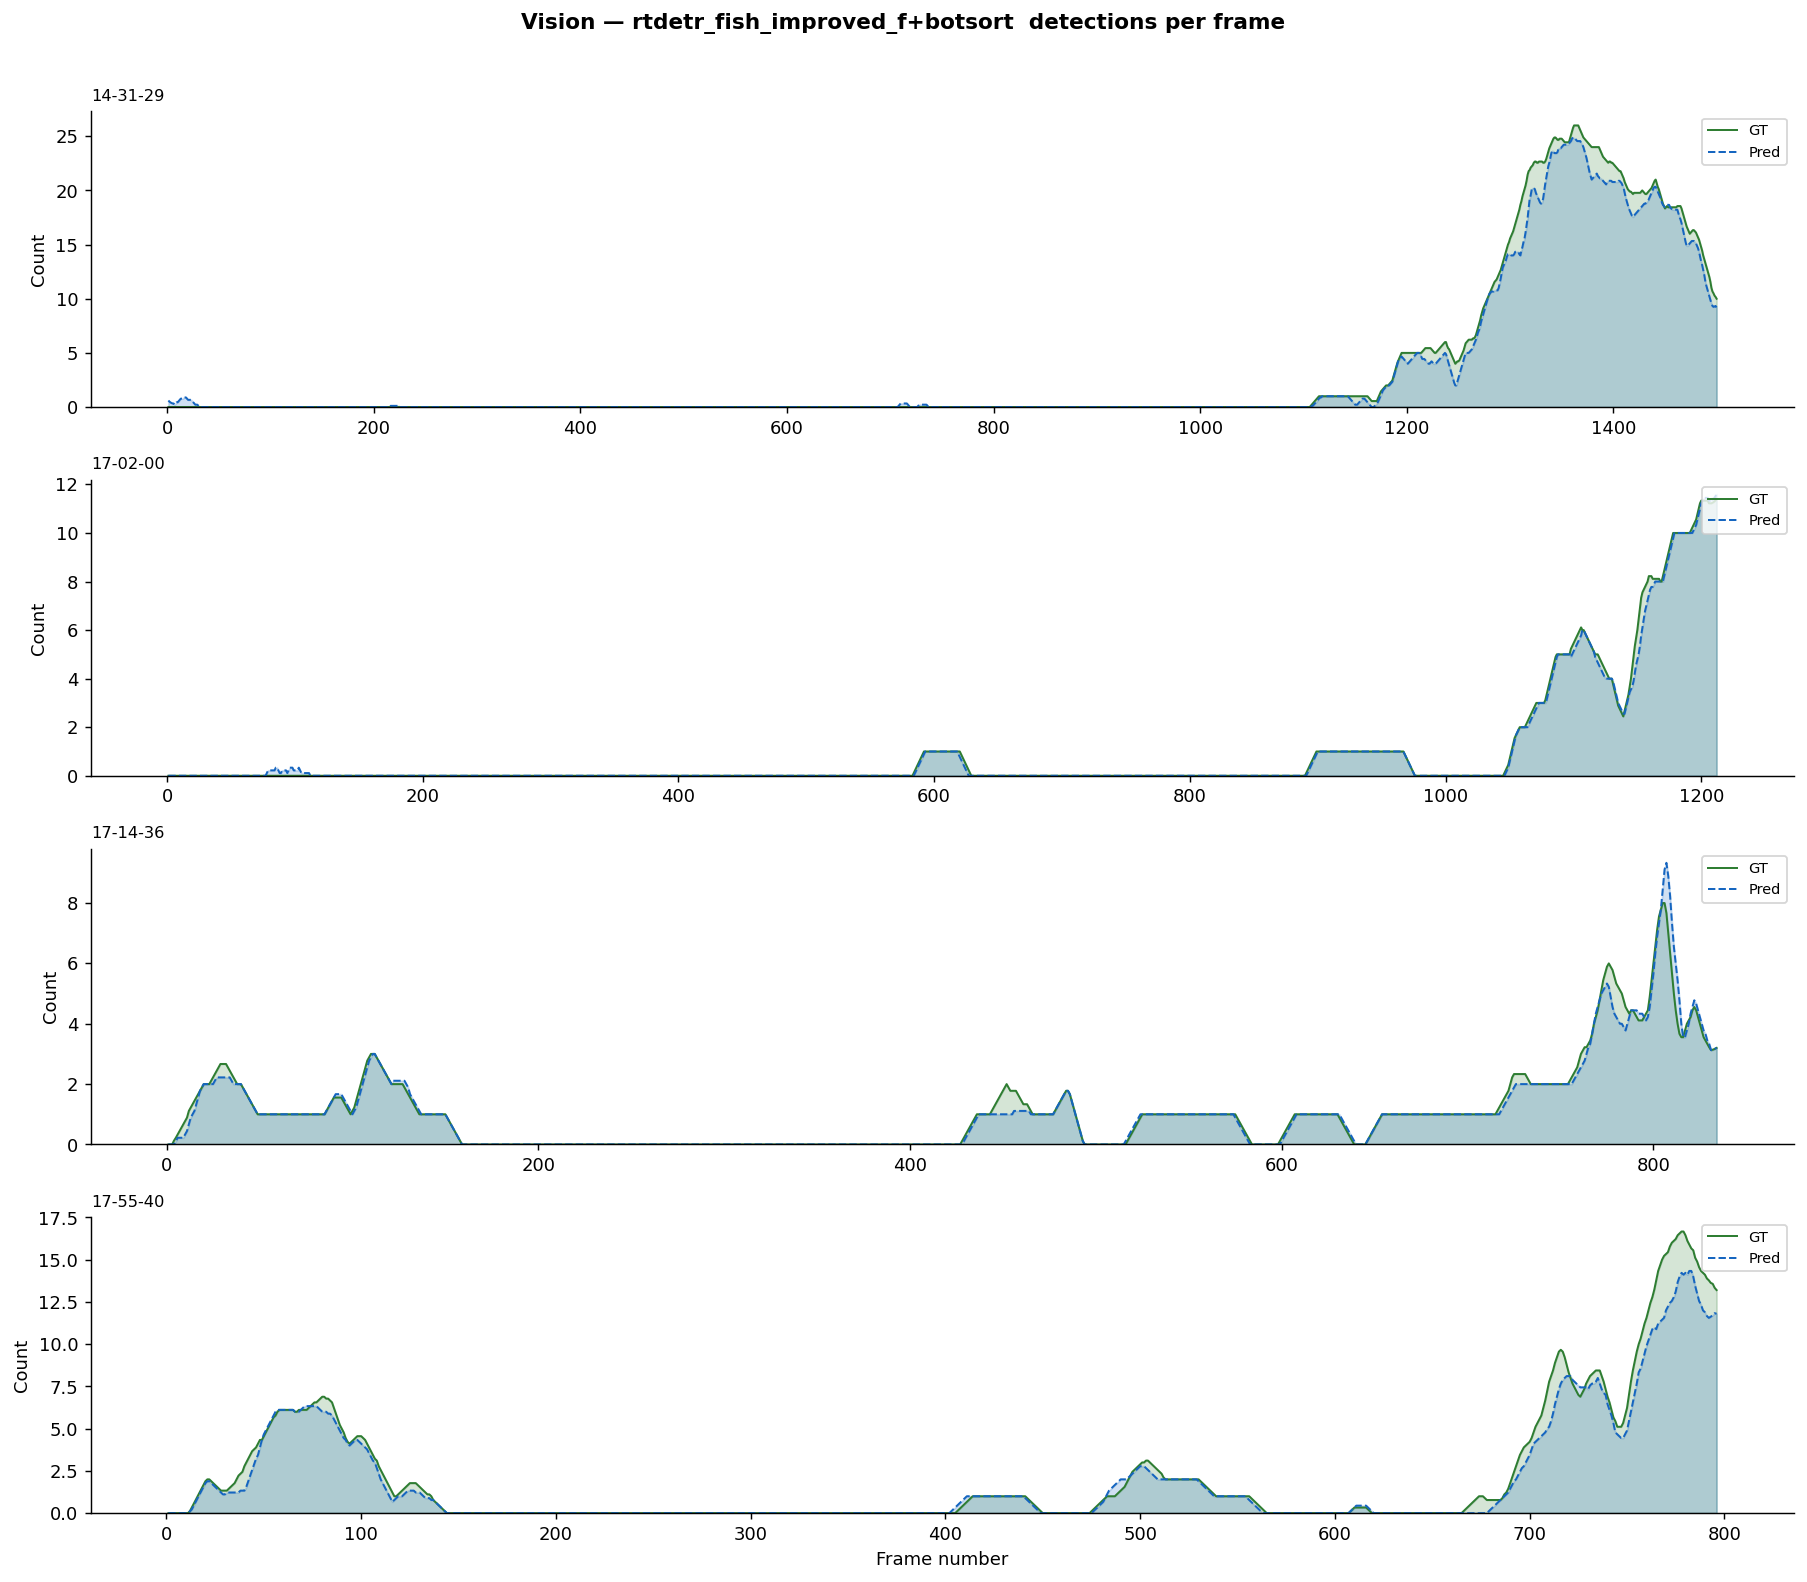

In [ ]:
for tracker in TRACKERS:
    run_tag = f"{MODEL_NAME}+{tracker}"
    fig = plot_det_timeline(gt_dfs, pred_by_tracker[tracker], total_frames,
                            title=f"Vision — {run_tag}  detections per frame")
    # plt.savefig(f"outputs/vision_{run_tag}_det_timeline.png", dpi=150, bbox_inches="tight")
    plt.show()


## 7  Cumulative ID switches over time

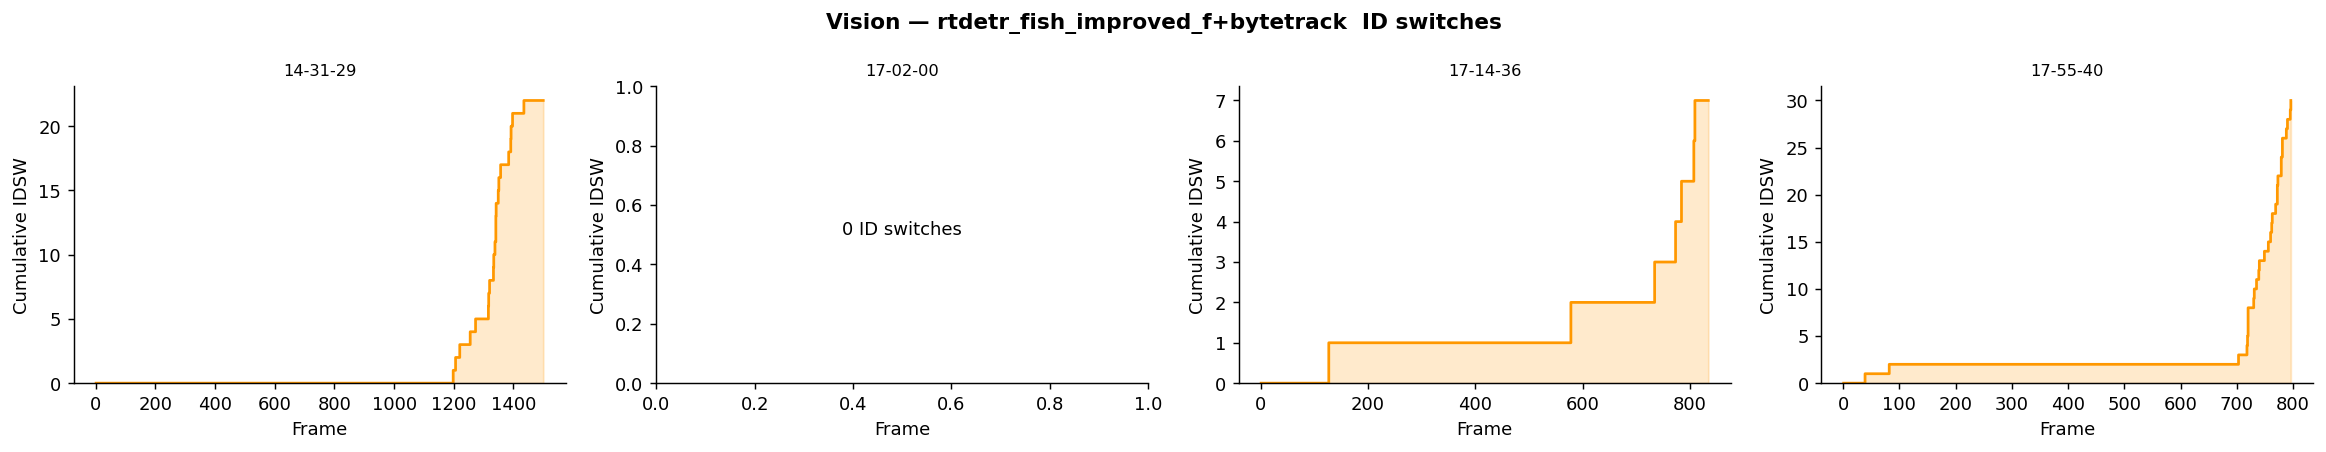

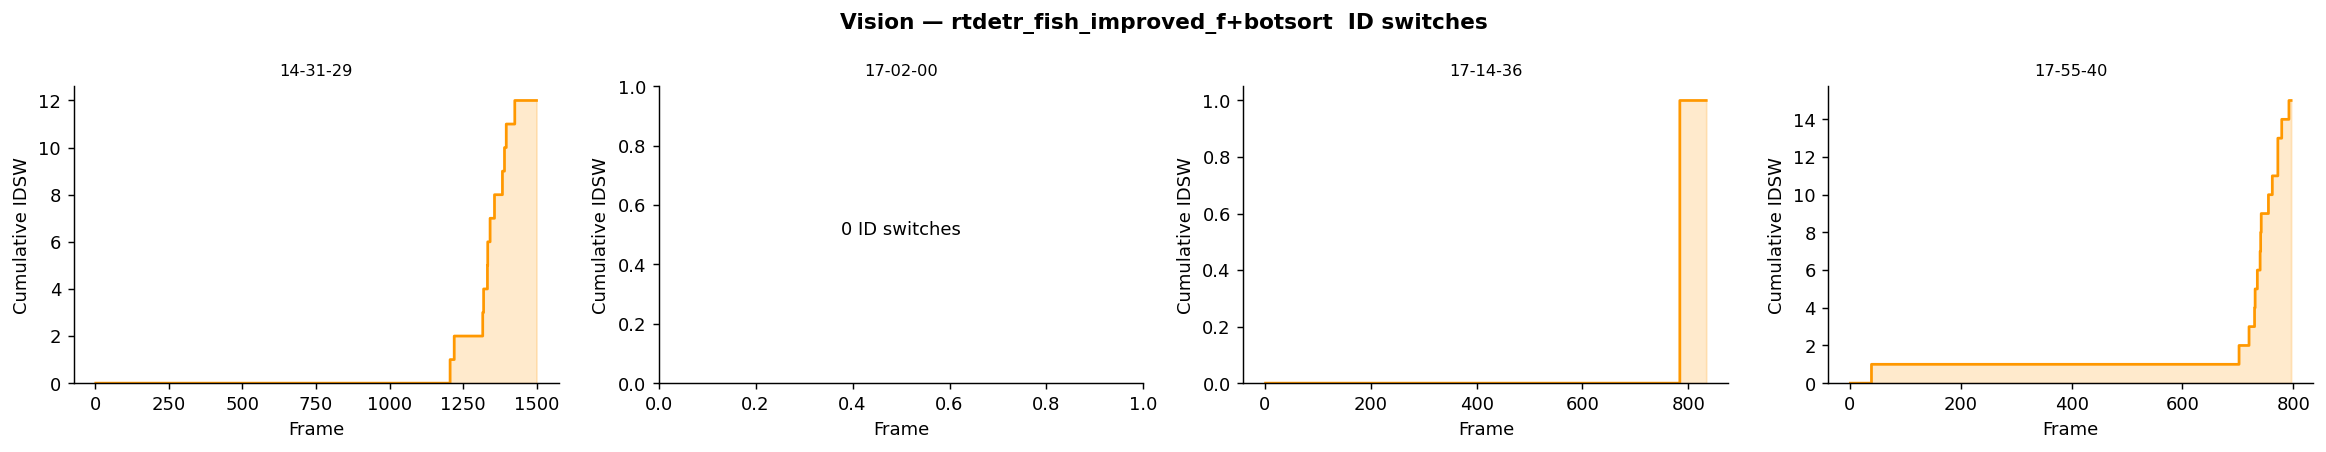

In [ ]:
for tracker in TRACKERS:
    run_tag = f"{MODEL_NAME}+{tracker}"
    fig = plot_id_switches(accs_by_tracker[tracker], total_frames,
                           title=f"Vision — {run_tag}  ID switches")
    # plt.savefig(f"outputs/vision_{run_tag}_id_switches.png", dpi=150, bbox_inches="tight")
    plt.show()


## 8  MT / PT / ML breakdown
Mostly Tracked (>80% life covered), Partially Tracked, Mostly Lost (<20%).

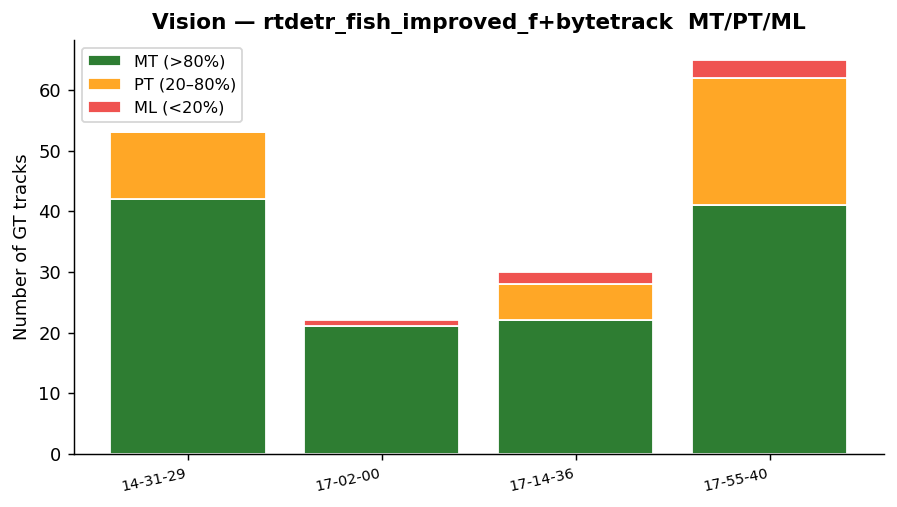

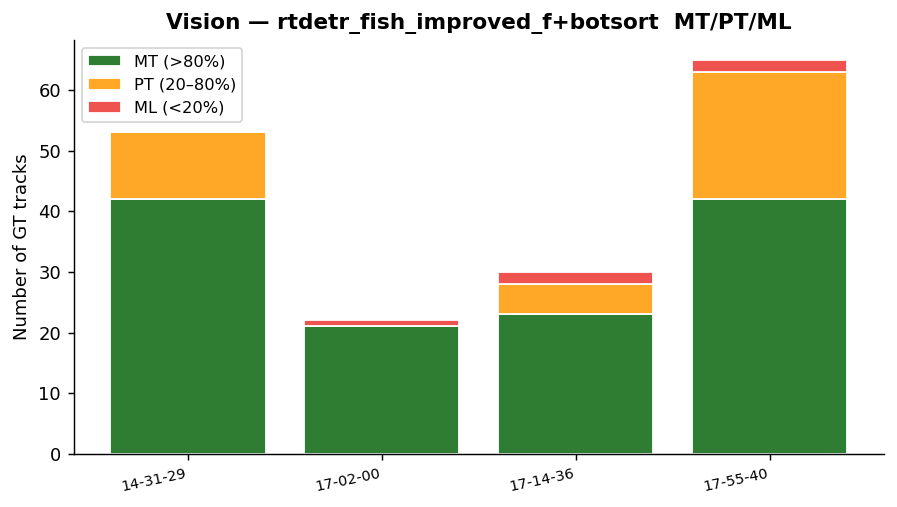

In [ ]:
for tracker in TRACKERS:
    run_tag   = f"{MODEL_NAME}+{tracker}"
    results   = results_by_tracker[tracker]
    seq_names = list(results.keys())
    mt_vals   = [int(results[s]["mostly_tracked"].iloc[0])   for s in seq_names]
    pt_vals   = [int(results[s]["partially_tracked"].iloc[0]) for s in seq_names]
    ml_vals   = [int(results[s]["mostly_lost"].iloc[0])       for s in seq_names]

    x = np.arange(len(seq_names))
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(x, mt_vals, label="MT (>80%)",  color="#2E7D32", edgecolor="white")
    ax.bar(x, pt_vals, bottom=mt_vals, label="PT (20–80%)", color="#FFA726", edgecolor="white")
    ax.bar(x, ml_vals, bottom=[m+p for m,p in zip(mt_vals,pt_vals)],
           label="ML (<20%)", color="#EF5350", edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels([s[-8:] for s in seq_names], rotation=12, ha="right", fontsize=8)
    ax.set_ylabel("Number of GT tracks")
    ax.set_title(f"Vision — {run_tag}  MT/PT/ML", fontweight="bold")
    ax.legend(fontsize=9)
    ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout()
#     plt.savefig(f"outputs/vision_{run_tag}_mt_pt_ml.png", dpi=150, bbox_inches="tight")
    plt.show()


## V1  Track + trail visualization
Shows bounding boxes and track IDs for one frame, plus the trajectory
of each track as a line over the last `TRAIL_FRAMES` frames.  
Edit `VIZ_TRACKER`, `VIZ_SEQ`, `VIZ_FRAME_NORM`, and `TRAIL_FRAMES` to configure.

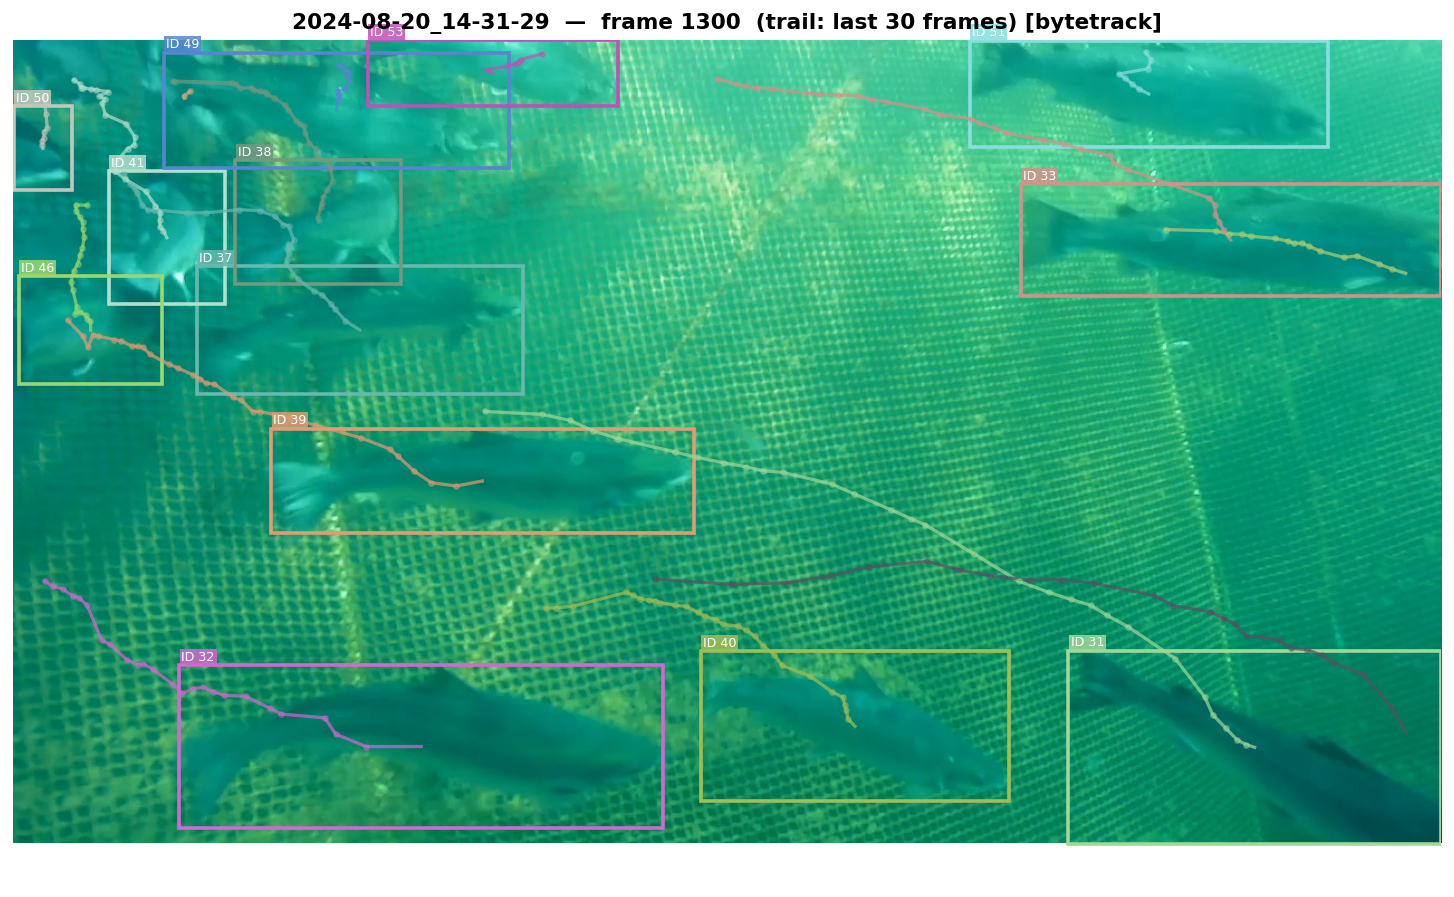

In [ ]:
# ── Config ────────────────────────────────────────────────────────────────────
VIZ_TRACKER    = TRACKERS[0]  # "bytetrack" or "botsort"
VIZ_SEQ        = SEQUENCES[0]
VIZ_FRAME_NORM = 1300
TRAIL_FRAMES   = 30

# ── Load image ────────────────────────────────────────────────────────────────
idir      = img_dir_for(VISION_ROOT / VIZ_SEQ, "vision")
fn_to_img = {i + 1: p for i, p in enumerate(collect_images(idir))}
assert VIZ_FRAME_NORM in fn_to_img, f"Frame {VIZ_FRAME_NORM} not found in sequence"
img_rgb = cv2.cvtColor(cv2.imread(str(fn_to_img[VIZ_FRAME_NORM])), cv2.COLOR_BGR2RGB)

pred = pred_by_tracker[VIZ_TRACKER][VIZ_SEQ]

# ── Per-track color (seeded by track id) ──────────────────────────────────────
def track_color(tid):
    rng = np.random.default_rng(seed=int(tid))
    return tuple(rng.integers(80, 230, size=3) / 255)

trail_start = max(1, VIZ_FRAME_NORM - TRAIL_FRAMES + 1)
trail_df    = pred[(pred["frame_norm"] >= trail_start) &
                   (pred["frame_norm"] <= VIZ_FRAME_NORM)].copy()
trail_df["cx"] = trail_df["x"] + trail_df["w"] / 2
trail_df["cy"] = trail_df["y"] + trail_df["h"] / 2

fig, ax = plt.subplots(figsize=(12, 7))
ax.imshow(img_rgb)

for tid, grp in trail_df.groupby("track_id"):
    grp = grp.sort_values("frame_norm")
    if len(grp) < 2:
        continue
    c = track_color(tid)
    ax.plot(grp["cx"], grp["cy"], "-", color=c, lw=1.8, alpha=0.7)
    ax.scatter(grp["cx"].iloc[:-1], grp["cy"].iloc[:-1], s=8, color=c, alpha=0.4, zorder=3)

for _, row in pred[pred["frame_norm"] == VIZ_FRAME_NORM].iterrows():
    tid = int(row.track_id)
    c   = track_color(tid)
    ax.add_patch(plt.Rectangle((row.x, row.y), row.w, row.h,
                               linewidth=2, edgecolor=c, facecolor="none"))
    ax.text(row.x + 2, row.y - 4, f"ID {tid}", fontsize=7, color="white",
            bbox=dict(facecolor=c, alpha=0.85, pad=1, edgecolor="none"))

ax.set_title(f"{VIZ_SEQ}  —  frame {VIZ_FRAME_NORM}  "
             f"(trail: last {TRAIL_FRAMES} frames) [{VIZ_TRACKER}]", fontweight="bold")
ax.axis("off")
plt.tight_layout()
# plt.savefig(f"outputs/vision_{VIZ_TRACKER}_trail_viz.png", dpi=150, bbox_inches="tight")
plt.show()


## V2  GT vs inference frame comparison
Green = ground truth boxes, red = predicted boxes.

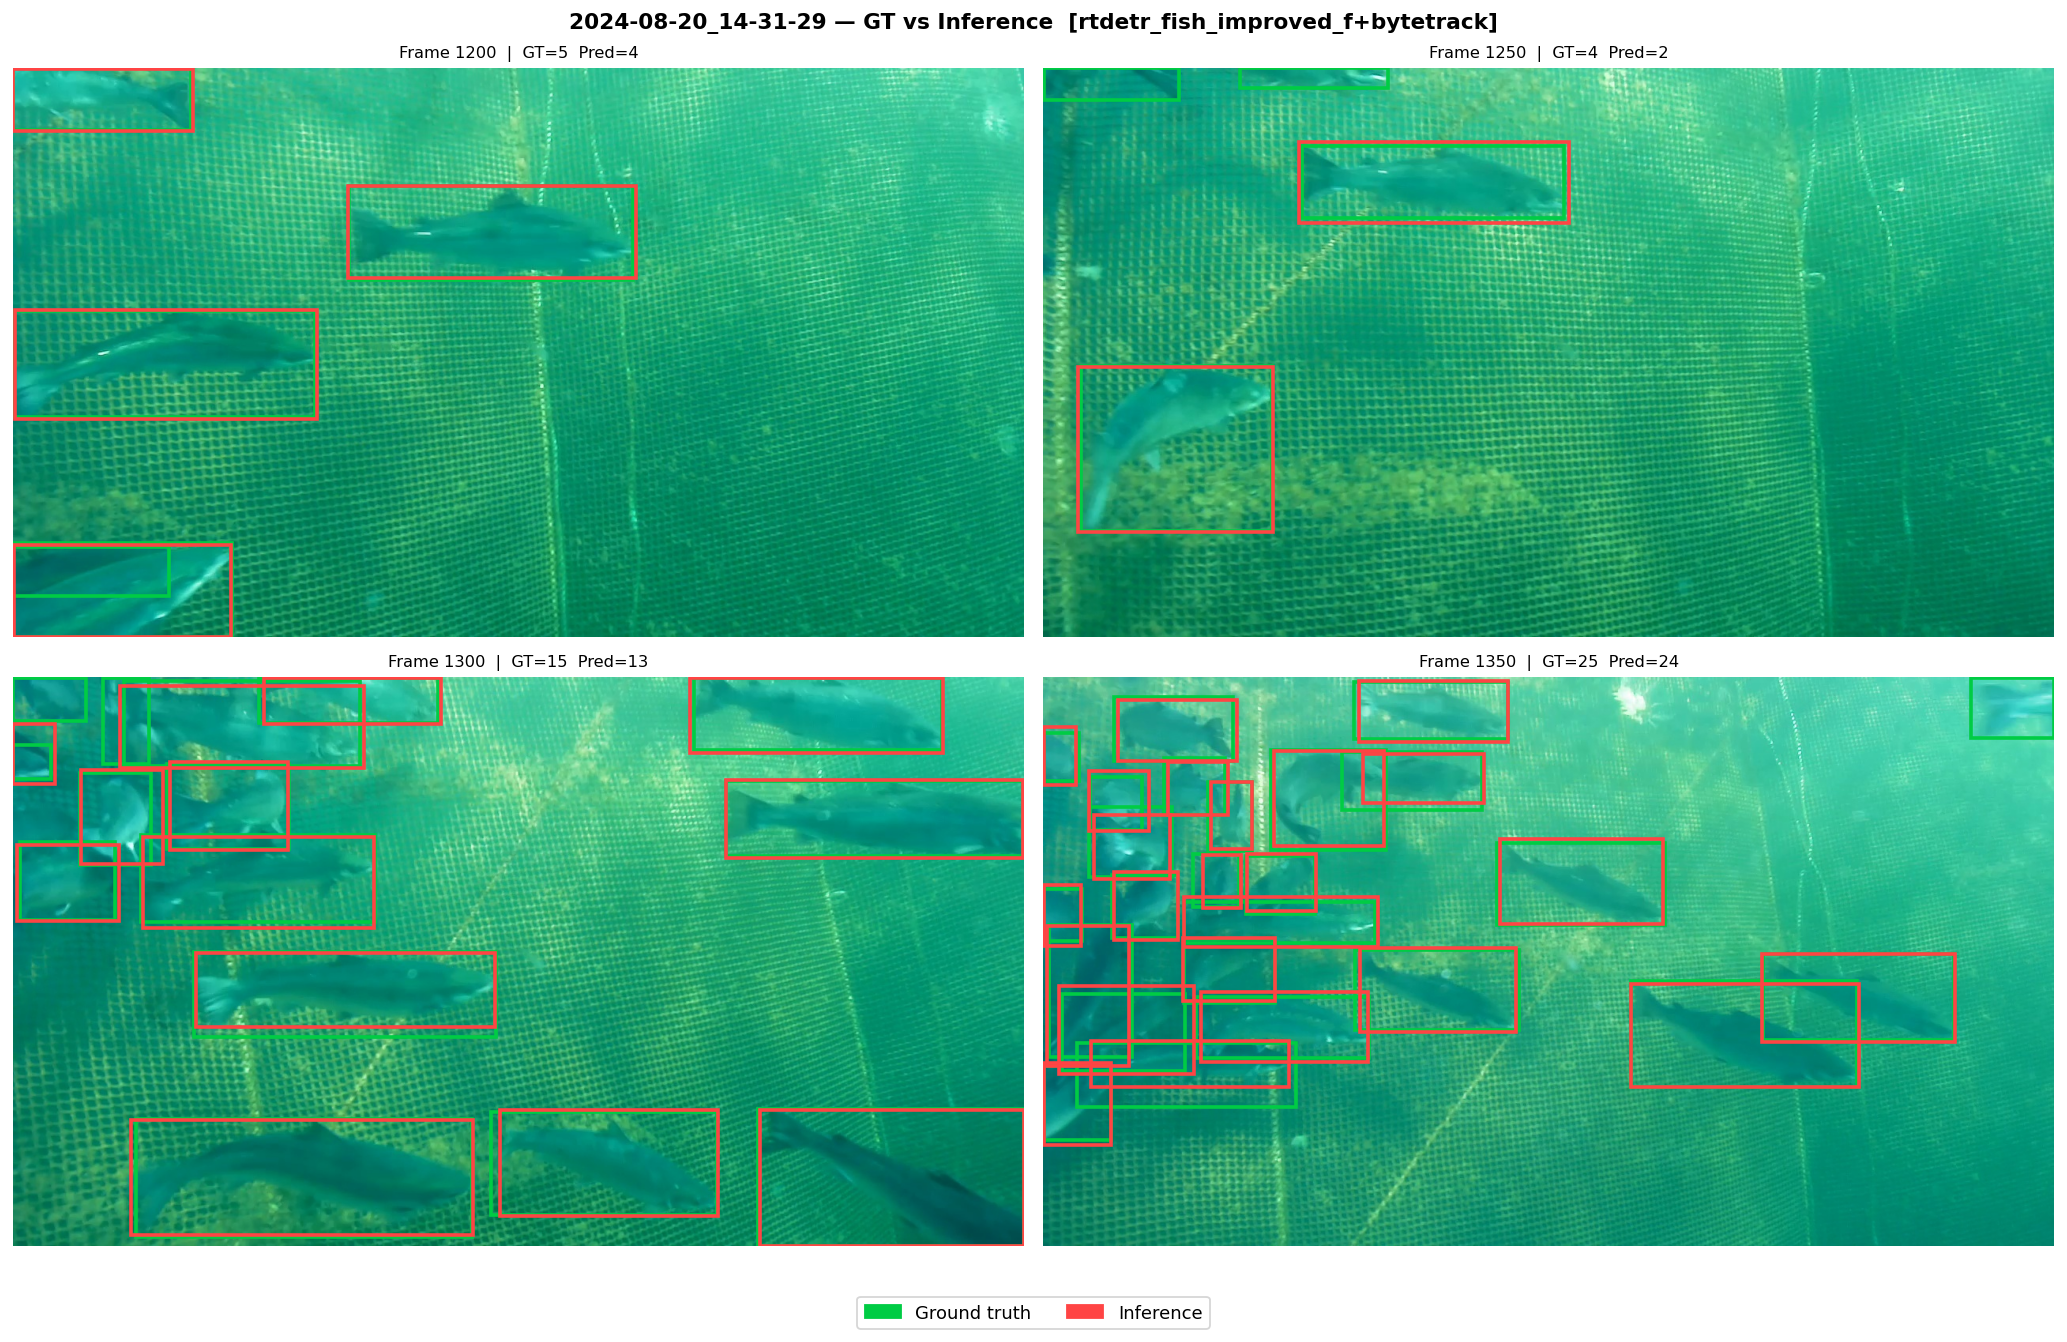

In [ ]:
# ── Config ────────────────────────────────────────────────────────────────────
CMP_TRACKER    = TRACKERS[0]  # "bytetrack" or "botsort"
COMPARE_SEQ    = SEQUENCES[0]
COMPARE_FRAMES = [1200, 1250, 1300, 1350]
NCOLS          = 2

GT_COLOR   = "#00CC44"
PRED_COLOR = "#FF4444"

idir_c      = img_dir_for(VISION_ROOT / COMPARE_SEQ, "vision")
fn_to_img_c = {i + 1: p for i, p in enumerate(collect_images(idir_c))}
gt_c        = gt_dfs[COMPARE_SEQ]
pred_c      = pred_by_tracker[CMP_TRACKER][COMPARE_SEQ]

valid_frames = [fn for fn in COMPARE_FRAMES if fn in fn_to_img_c]
nrows = (len(valid_frames) + NCOLS - 1) // NCOLS
fig, axes = plt.subplots(nrows, NCOLS, figsize=(NCOLS * 8, nrows * 5))
axes = np.array(axes).flatten()

for i, fn in enumerate(valid_frames):
    ax = axes[i]
    img_rgb = cv2.cvtColor(cv2.imread(str(fn_to_img_c[fn])), cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)
    for _, row in gt_c[gt_c["frame_norm"] == fn].iterrows():
        ax.add_patch(plt.Rectangle((row.x, row.y), row.w, row.h,
                                   linewidth=2, edgecolor=GT_COLOR, facecolor="none"))
    for _, row in pred_c[pred_c["frame_norm"] == fn].iterrows():
        ax.add_patch(plt.Rectangle((row.x, row.y), row.w, row.h,
                                   linewidth=2, edgecolor=PRED_COLOR, facecolor="none"))
    n_gt   = (gt_c["frame_norm"]   == fn).sum()
    n_pred = (pred_c["frame_norm"] == fn).sum()
    ax.set_title(f"Frame {fn}  |  GT={n_gt}  Pred={n_pred}", fontsize=9)
    ax.axis("off")

for j in range(len(valid_frames), len(axes)):
    axes[j].set_visible(False)

fig.legend(
    handles=[
        mpatches.Patch(color=GT_COLOR,   label="Ground truth"),
        mpatches.Patch(color=PRED_COLOR, label="Inference"),
    ],
    loc="lower center", ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.04),
)
run_tag_cmp = f"{MODEL_NAME}+{CMP_TRACKER}"
fig.suptitle(f"{COMPARE_SEQ} — GT vs Inference  [{run_tag_cmp}]",
             fontsize=12, fontweight="bold")
plt.tight_layout()
# plt.savefig(f"outputs/vision_{run_tag_cmp}_gt_vs_pred.png", dpi=150, bbox_inches="tight")
plt.show()


## Combined — all sequences
Aggregates all selected sequences into a single evaluation for each tracker.
Frame and track IDs are offset per sequence to avoid collisions.


── BYTETRACK combined (4 seq) ──
HOTA=82.7%  MOTA=87.6%  IDF1=87.9%  IDSW=59

Run: rtdetr_fish_improved_f+bytetrack


,Sequence,HOTA,DetA,AssA,MOTA,IDF1,MOTP,Recall,Precision,FP,FN,IDSW,MT,ML,GT tracks
0,14-31-29,81.2%,77.3%,89.1%,89.1%,87.9%,6.7%,90.6%,98.9%,51,469,22,42,0,53
1,17-02-00,96.2%,92.7%,100.0%,95.8%,97.9%,2.1%,96.6%,99.3%,8,38,0,21,1,22
2,17-14-36,86.1%,84.9%,87.7%,88.5%,86.1%,2.8%,93.0%,96.2%,33,63,7,22,2,30
3,17-55-40,75.8%,68.5%,86.5%,77.0%,82.0%,7.6%,83.0%,95.2%,70,284,30,41,3,65
4,COMBINED,82.7%,78.0%,90.1%,87.6%,87.9%,5.8%,90.1%,98.0%,162,854,59,126,6,170


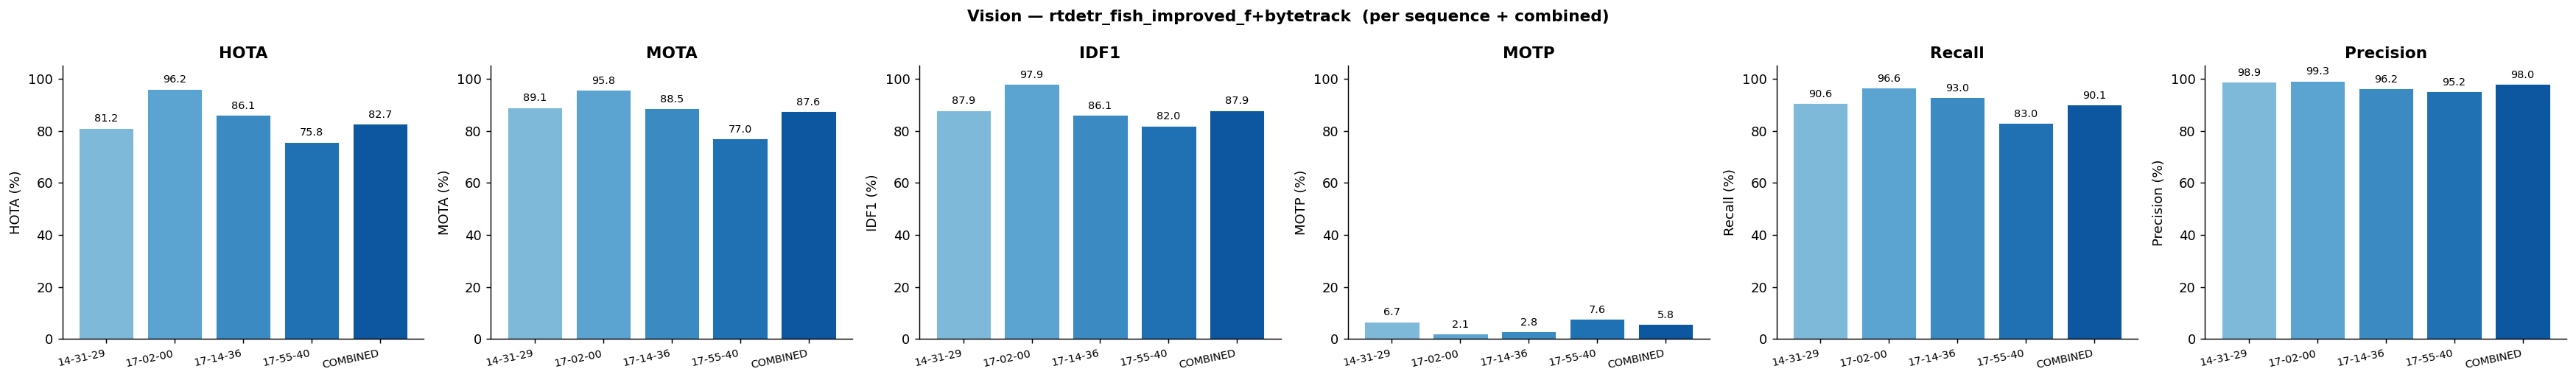

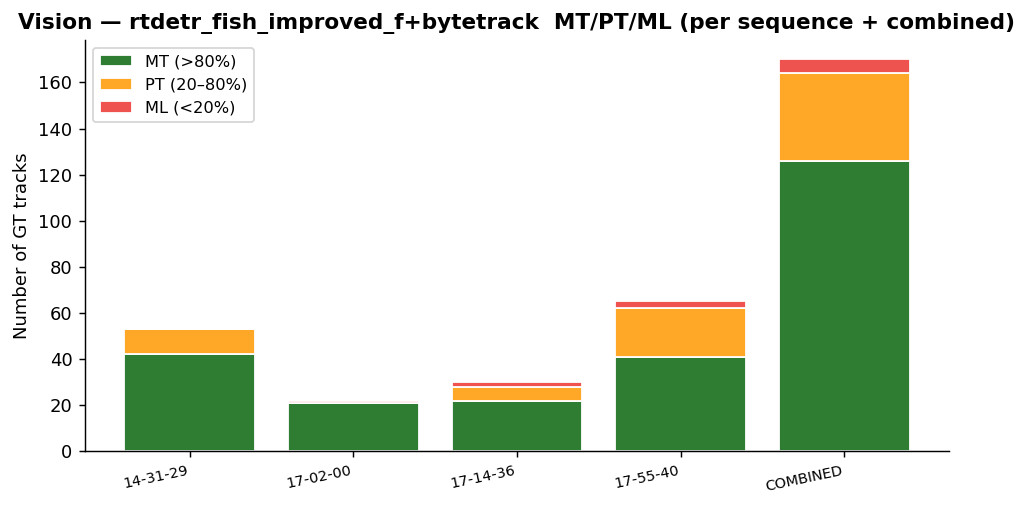


── BOTSORT combined (4 seq) ──
HOTA=84.5%  MOTA=88.4%  IDF1=89.7%  IDSW=28

Run: rtdetr_fish_improved_f+botsort


,Sequence,HOTA,DetA,AssA,MOTA,IDF1,MOTP,Recall,Precision,FP,FN,IDSW,MT,ML,GT tracks
0,14-31-29,83.0%,77.6%,92.8%,89.7%,89.2%,6.6%,91.0%,98.9%,51,449,12,42,0,53
1,17-02-00,96.1%,92.5%,100.0%,95.7%,97.8%,2.1%,96.6%,99.1%,10,38,0,21,1,22
2,17-14-36,91.9%,85.4%,99.4%,89.7%,94.5%,2.8%,93.5%,96.1%,34,58,1,23,2,30
3,17-55-40,76.5%,69.2%,87.2%,79.3%,82.8%,7.5%,83.9%,95.8%,61,269,15,42,2,65
4,COMBINED,84.5%,78.3%,93.6%,88.4%,89.7%,5.7%,90.6%,98.0%,156,814,28,128,5,170


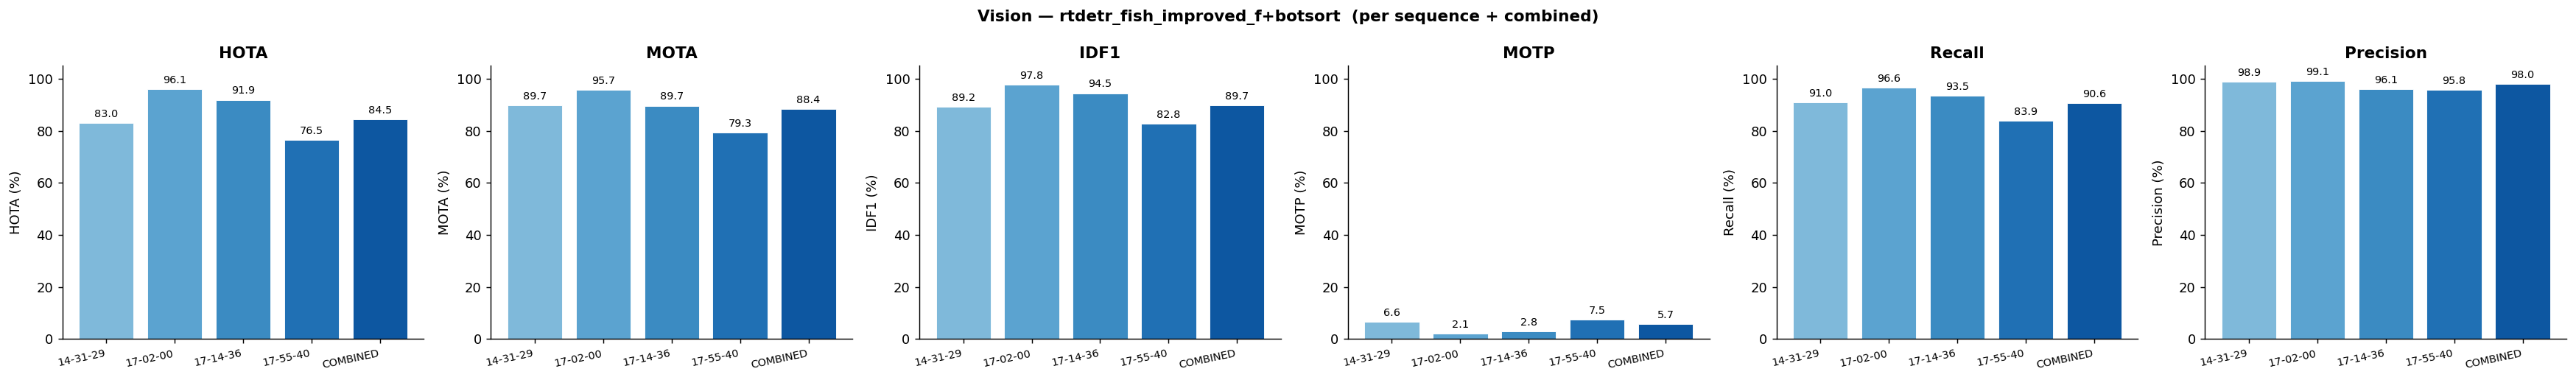

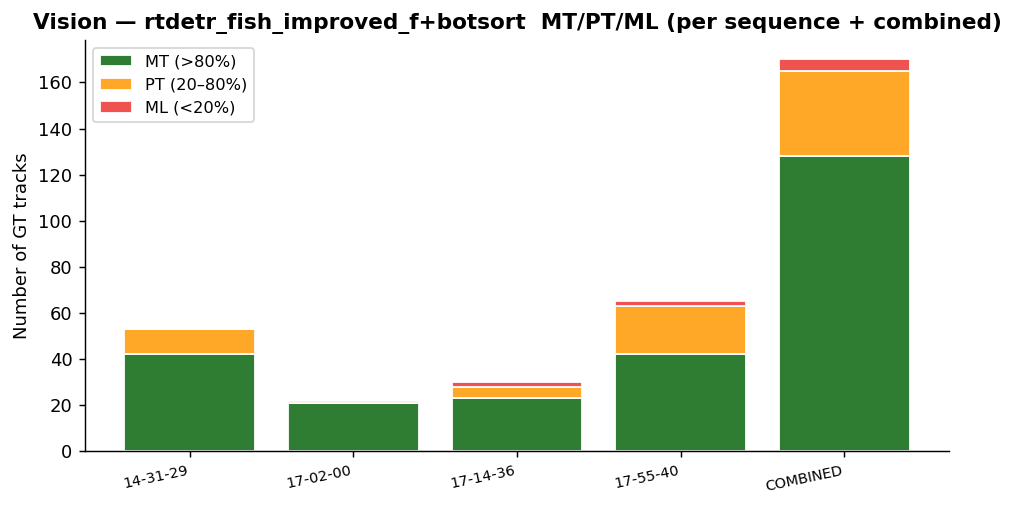

In [ ]:
_OFF = 10_000

for tracker in TRACKERS:
    run_tag   = f"{MODEL_NAME}+{tracker}"
    results   = results_by_tracker[tracker]
    pred_dfs  = pred_by_tracker[tracker]

    gt_combined = pd.concat(
        [gt_dfs[s].assign(frame_norm=gt_dfs[s]["frame_norm"] + i * _OFF,
                          track_id  =gt_dfs[s]["track_id"]   + i * _OFF)
         for i, s in enumerate(SEQUENCES)], ignore_index=True)
    pred_combined = pd.concat(
        [pred_dfs[s].assign(frame_norm=pred_dfs[s]["frame_norm"] + i * _OFF,
                            track_id  =pred_dfs[s]["track_id"]   + i * _OFF)
         for i, s in enumerate(SEQUENCES)], ignore_index=True)

    _, summ_comb = compute_metrics(gt_combined, pred_combined, iou_threshold=IOU_MATCH)
    hota_comb    = compute_hota(gt_combined, pred_combined)
    for k, v in hota_comb.items():
        summ_comb[k] = v

    print(f"\n── {tracker.upper()} combined ({len(SEQUENCES)} seq) ──")
    print(f"HOTA={hota_comb['hota']*100:.1f}%  "
          f"MOTA={float(summ_comb['mota'].iloc[0])*100:.1f}%  "
          f"IDF1={float(summ_comb['idf1'].iloc[0])*100:.1f}%  "
          f"IDSW={int(summ_comb['num_switches'].iloc[0])}")

    results_all = dict(results) | {"COMBINED": summ_comb}
    print(f"\nRun: {run_tag}")
    display(build_summary_table(results_all))

    fig = plot_metrics_bar(
        results_all,
        metrics=("HOTA", "MOTA", "IDF1", "MOTP", "Recall", "Precision"),
        title=f"Vision — {run_tag}  (per sequence + combined)",
    )
    # plt.savefig(f"outputs/vision_{run_tag}_combined_metrics_bar.png", dpi=150, bbox_inches="tight")
    plt.show()

    _seq_all = list(results_all.keys())
    _mt = [int(results_all[s]["mostly_tracked"].iloc[0])   for s in _seq_all]
    _pt = [int(results_all[s]["partially_tracked"].iloc[0]) for s in _seq_all]
    _ml = [int(results_all[s]["mostly_lost"].iloc[0])       for s in _seq_all]

    x = np.arange(len(_seq_all))
    fig, ax = plt.subplots(figsize=(max(7, len(_seq_all) * 1.5), 4))
    ax.bar(x, _mt, label="MT (>80%)",  color="#2E7D32", edgecolor="white")
    ax.bar(x, _pt, bottom=_mt, label="PT (20–80%)", color="#FFA726", edgecolor="white")
    ax.bar(x, _ml, bottom=[m + p for m, p in zip(_mt, _pt)],
           label="ML (<20%)", color="#EF5350", edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels([s[-8:] for s in _seq_all], rotation=12, ha="right", fontsize=8)
    ax.set_ylabel("Number of GT tracks")
    ax.set_title(f"Vision — {run_tag}  MT/PT/ML (per sequence + combined)", fontweight="bold")
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    # plt.savefig(f"outputs/vision_{run_tag}_combined_mt_pt_ml.png", dpi=150, bbox_inches="tight")
    plt.show()
